# HAT Layer 1 — Prompts per Run vs Clustering Accuracy

The dataset has 12 independent runs, each containing 40 prompts
(20 neutral + 20 emotional) in a fixed order shared across all runs.

For each target size N in [20, 25, 30, 35, 40]:
- Take floor(N/2) neutral **and** floor(N/2) emotional prompts from each run
  (always balanced, always the same selection)
- Concatenate across all 12 runs → 12 × 2 × floor(N/2) total trials
- Run L1-only KMeans clustering (single best feature + multi-feature sweep)

X-axis: target prompts per run | Y-axis: clustering accuracy (%)


## §1 — Imports

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')


Imports OK


## §2 — Configuration

In [ ]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR = BASE_DIR / 'data' / '70b'

RUNS = ['1', '2', '3','4','5','6', '7']


# Target prompts per run — floor(N/2) neutral + floor(N/2) emotional are taken
# so the subset is always perfectly balanced regardless of N being odd or even
SUBSET_SIZES = [20,22,24,26,28,30,32,34,36,38,40]

HAT_L1 = {
    'hat_SPU':             'Spurious interrupt',
    'hat_MCE':             'Machine Check Exception',
    'hat_TLB':             'TLB Shootdown (IPI)',
    'tlb:tlb_flush':       'TLB Shootdown (tracepoint, 1ms)',
    'mce:mce_record':      'MCE tracepoint',
    'core_power.throttle': 'Thermal/Power Anomaly',
    'uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/': 'ECC Correctable Error',
}

EXCLUDE_INDICATORS = {
    'hat_NMI', 'hat_PMI', 'hat_LOC', 'hat_RES', 'hat_CAL', 'hat_MCP',
    'hat_BLOCK', 'hat_IWI', 'hat_NET_RX', 'hat_NET_TX',
    'hat_RCU', 'hat_SCHED', 'hat_TASKLET', 'hat_TIMER',
    'irq:irq_handler_entry', 'irq:irq_handler_exit',
    'irq:softirq_entry', 'irq:softirq_exit', 'irq:softirq_raise',
}

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Per-class    : {[N//2 for N in SUBSET_SIZES]} (neutral = emotional)')
print(f'  Total trials : {[12 * 2 * (N//2) for N in SUBSET_SIZES]}')


Configuration OK
  Runs         : ['1', '2', '3', '4', '5', '6', '7']
  Subset sizes : [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
  Per-class    : [10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 20] (neutral = emotional)
  Total trials : [240, 240, 264, 264, 288, 288, 312, 312, 336, 336, 360, 360, 384, 384, 408, 408, 432, 432, 456, 456, 480]


## §3 — Load data

In [3]:
dfs = []
loaded, missing = [], []

for run in RUNS:
    p = DATA_DIR / f'independent{run}.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['run'] = run
        # Preserve within-run prompt order using the row index within each run
        df['_prompt_order'] = range(len(df))
        dfs.append(df)
        loaded.append(run)
    else:
        missing.append(run)

if missing:
    print(f'⚠  Not found (skipping): {missing}')

df_all = pd.concat(dfs, ignore_index=True)

print(f'Loaded {len(loaded)} runs: {loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Per-run counts: {df_all.groupby("run").size().sort_index().to_dict()}')


Loaded 7 runs: ['1', '2', '3', '4', '5', '6', '7']
  Total trials : 280
  Neutral      : 140
  Emotional    : 140
  Per-run counts: {'1': 40, '2': 40, '3': 40, '4': 40, '5': 40, '6': 40, '7': 40}


## §4 — Identify active L1 feature columns

In [4]:
def indicator_of(col): return col.split('__', 1)[0]

all_feat_cols = [c for c in df_all.columns if '__' in c]

# Drop indicators whose mean_rate is identically zero (SPU, MCE, ECC on healthy node)
zero_rate_inds = set()
for ind in sorted(set(indicator_of(c) for c in all_feat_cols)):
    mc = f'{ind}__mean_rate'
    if mc in df_all.columns:
        vals = pd.to_numeric(df_all[mc], errors='coerce').fillna(0)
        if (vals.abs() < 1e-9).all():
            zero_rate_inds.add(ind)

l1_cols = [
    c for c in all_feat_cols
    if indicator_of(c) in HAT_L1
    and indicator_of(c) not in EXCLUDE_INDICATORS
    and indicator_of(c) not in zero_rate_inds
]

active_l1_inds = sorted(set(indicator_of(c) for c in l1_cols))
print(f'Active L1 indicators : {active_l1_inds}')
print(f'Active L1 feature cols: {len(l1_cols)}')
print(f'Excluded (all-zero)  : {sorted(zero_rate_inds & set(HAT_L1))}')


Active L1 indicators : ['core_power.throttle', 'hat_TLB', 'tlb:tlb_flush']
Active L1 feature cols: 30
Excluded (all-zero)  : ['hat_MCE', 'hat_SPU', 'mce:mce_record', 'uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/']


## §5 — Clustering helpers

In [5]:
def cluster_accuracy(X, y_true):
    """KMeans k=2, majority-vote alignment, returns (ari, accuracy, n_mismatches)."""
    km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
    labels = km.labels_
    ari = adjusted_rand_score(y_true, labels)
    cm = confusion_matrix(y_true, labels)
    n_err = min(cm[0,1]+cm[1,0], cm[0,0]+cm[1,1])
    acc = 1 - n_err / cm.sum()
    return ari, acc, int(n_err)


def best_single_l1(X_raw, y_true, ranked_cols):
    """Try each L1 column individually; return best by mismatch count."""
    best = None
    for col in ranked_cols:
        if col not in X_raw.columns:
            continue
        X = StandardScaler().fit_transform(
            X_raw[[col]].apply(pd.to_numeric, errors='coerce').fillna(0))
        ari, acc, n_err = cluster_accuracy(X, y_true)
        if best is None or n_err < best[3]:
            best = (col, ari, acc, n_err)
    return (None, np.nan, np.nan, np.nan) if best is None else best


def best_multi_l1(X_raw, y_true, ranked_cols, k_max=15):
    """Sweep K=1..k_max using ranked_cols order; return best by mismatch."""
    valid = [c for c in ranked_cols if c in X_raw.columns]
    best = None
    for K in range(1, min(k_max, len(valid)) + 1):
        X = StandardScaler().fit_transform(
            X_raw[valid[:K]].apply(pd.to_numeric, errors='coerce').fillna(0))
        ari, acc, n_err = cluster_accuracy(X, y_true)
        if best is None or n_err < best[3]:
            best = (ari, acc, n_err, K)
    return best if best else (np.nan, np.nan, np.nan, 0)


print('Helpers defined.')


Helpers defined.


## §6 — Pre-rank L1 features on the full dataset

The column ranking is fixed once on all 480 trials and then applied
consistently to every subset.  This avoids re-ranking within subsets
(which would make results incomparable across sizes).


In [6]:
X_l1_full = df_all[l1_cols].apply(pd.to_numeric, errors='coerce')
X_l1_full = X_l1_full.fillna(X_l1_full.median())
y_full = (df_all['condition'] == 'emotional').astype(int).values

scores = []
for col in l1_cols:
    X = StandardScaler().fit_transform(X_l1_full[[col]])
    _, _, n_err = cluster_accuracy(X, y_full)
    scores.append((col, n_err))

scores.sort(key=lambda x: x[1])
l1_ranked = [s[0] for s in scores]

print('L1 feature ranking (by mismatch on full 480-trial dataset):')
for i, (col, n_err) in enumerate(scores[:12]):
    print(f'  {i+1:2d}.  {col:<55}  mismatch={n_err}')


L1 feature ranking (by mismatch on full 480-trial dataset):
   1.  core_power.throttle__mean_rate                           mismatch=120
   2.  core_power.throttle__burst_rate                          mismatch=127
   3.  hat_TLB__burst_clustering                                mismatch=129
   4.  tlb:tlb_flush__variance                                  mismatch=131
   5.  core_power.throttle__burst_clustering                    mismatch=131
   6.  tlb:tlb_flush__lz_complexity                             mismatch=132
   7.  core_power.throttle__lz_complexity                       mismatch=132
   8.  tlb:tlb_flush__burst_clustering                          mismatch=134
   9.  hat_TLB__burst_rate                                      mismatch=134
  10.  tlb:tlb_flush__p90_p10                                   mismatch=135
  11.  tlb:tlb_flush__burst_rate                                mismatch=135
  12.  core_power.throttle__slope                               mismatch=135


## §7 — Subset sweep

For each target size N, take floor(N/2) neutral and floor(N/2) emotional
prompts from every run (in their within-run prompt order), concatenate,
and cluster.


In [7]:
results = []

for N in SUBSET_SIZES:
    n_per_class = N // 2  # balanced: exactly this many neutral AND emotional per run

    sub_runs = []
    for run in RUNS:
        df_run = df_all[df_all['run'] == run].sort_values('_prompt_order')

        neut = df_run[df_run.condition == 'neutral'  ].head(n_per_class)
        emot = df_run[df_run.condition == 'emotional'].head(n_per_class)

        if len(neut) < n_per_class or len(emot) < n_per_class:
            print(f'  ⚠  Run {run}: insufficient trials for N={N}, skipping run.')
            continue

        sub_runs.append(pd.concat([neut, emot]))

    if not sub_runs:
        continue

    sub = pd.concat(sub_runs, ignore_index=True)
    y_sub = (sub['condition'] == 'emotional').astype(int).values
    actual_N   = len(sub) // len(RUNS)   # actual prompts per run used
    total      = len(sub)

    X_sub = sub[l1_cols].apply(pd.to_numeric, errors='coerce')
    X_sub = X_sub.fillna(X_sub.median())

    col1, ari1, acc1, err1 = best_single_l1(X_sub, y_sub, l1_ranked)
    arim, accm, errm, Km   = best_multi_l1 (X_sub, y_sub, l1_ranked)

    results.append({
        'N_target':  N,
        'N_per_class': n_per_class,
        'total':     total,
        'single_col': col1,
        'single_ari': ari1,
        'single_acc': acc1,
        'single_err': err1,
        'multi_ari':  arim,
        'multi_acc':  accm,
        'multi_err':  errm,
        'multi_K':    Km,
    })

    print(f'N={N:2d} (×{n_per_class} per class per run → {total} trials total) | '
          f'1-feat: acc={acc1:.3f}  ARI={ari1:.4f}  [{str(col1)[:40]}] | '
          f'multi K={Km}: acc={accm:.3f}  ARI={arim:.4f}')

res = pd.DataFrame(results)


N=20 (×10 per class per run → 140 trials total) | 1-feat: acc=0.600  ARI=0.0332  [tlb:tlb_flush__variance] | multi K=1: acc=0.536  ARI=-0.0019
N=21 (×10 per class per run → 140 trials total) | 1-feat: acc=0.600  ARI=0.0332  [tlb:tlb_flush__variance] | multi K=1: acc=0.536  ARI=-0.0019
N=22 (×11 per class per run → 154 trials total) | 1-feat: acc=0.578  ARI=0.0183  [core_power.throttle__burst_rate] | multi K=1: acc=0.532  ARI=-0.0022
N=23 (×11 per class per run → 154 trials total) | 1-feat: acc=0.578  ARI=0.0183  [core_power.throttle__burst_rate] | multi K=1: acc=0.532  ARI=-0.0022
N=24 (×12 per class per run → 168 trials total) | 1-feat: acc=0.583  ARI=0.0224  [tlb:tlb_flush__variance] | multi K=1: acc=0.548  ARI=0.0032
N=25 (×12 per class per run → 168 trials total) | 1-feat: acc=0.583  ARI=0.0224  [tlb:tlb_flush__variance] | multi K=1: acc=0.548  ARI=0.0032
N=26 (×13 per class per run → 182 trials total) | 1-feat: acc=0.577  ARI=0.0184  [core_power.throttle__burst_rate] | multi K=1: 

## §8 — Plot

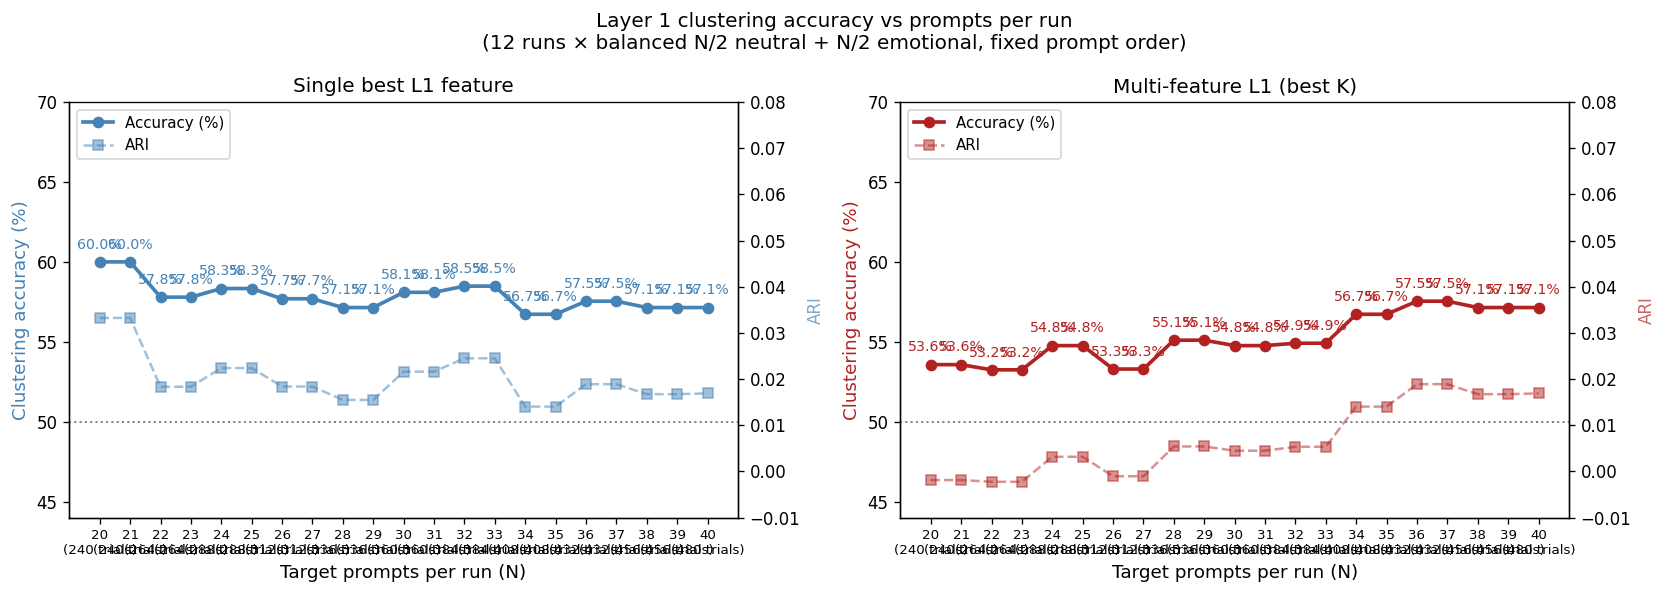

Plot saved to l1_subset_accuracy.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, acc_col, ari_col, title, color in [
    (axes[0], 'single_acc', 'single_ari', 'Single best L1 feature', 'steelblue'),
    (axes[1], 'multi_acc',  'multi_ari',  'Multi-feature L1 (best K)', 'firebrick'),
]:
    xs  = res['N_target'].values
    acc = res[acc_col].values * 100
    ari = res[ari_col].values

    ax2 = ax.twinx()
    ax.plot(xs, acc, marker='o', lw=2.2, color=color, label='Accuracy (%)', zorder=3)
    ax2.plot(xs, ari, marker='s', lw=1.5, ls='--', color=color, alpha=0.5,
             label='ARI', zorder=2)

    for x, a, r in zip(xs, acc, ari):
        ax.annotate(f'{a:.1f}%', (x, a), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8.5, color=color)

    ax.axhline(50, color='grey', lw=1.2, ls=':', zorder=1)
    ax.set_xlabel('Target prompts per run (N)', fontsize=11)
    ax.set_ylabel('Clustering accuracy (%)', fontsize=11, color=color)
    ax2.set_ylabel('ARI', fontsize=10, color=color, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(xs)
    ax.set_xticklabels([f'{n}\n({12*2*(n//2)} trials)' for n in xs], fontsize=8)
    ax.set_ylim(44, 70)
    ax2.set_ylim(-0.01, 0.08)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
    ax.spines[['top']].set_visible(False)

plt.suptitle('Layer 1 clustering accuracy vs prompts per run\n'
             '(12 runs × balanced N/2 neutral + N/2 emotional, fixed prompt order)',
             fontsize=12)
plt.tight_layout()
plt.savefig('l1_subset_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to l1_subset_accuracy.png')


## §9 — Summary table

In [9]:
print('Layer 1 clustering results by prompts-per-run subset')
print('=' * 90)
print(f'  {"N":>4}  {"×/class":>7}  {"Total":>6}  '
      f'{"1-feat acc":>10}  {"1-feat ARI":>10}  '
      f'{"multi acc":>10}  {"multi ARI":>10}  {"K":>4}')
print('-' * 90)
for _, r in res.iterrows():
    print(f'  {int(r.N_target):>4}  {int(r.N_per_class):>7}  {int(r.total):>6}  '
          f'  {r.single_acc:>9.3f}  {r.single_ari:>10.4f}  '
          f'  {r.multi_acc:>9.3f}  {r.multi_ari:>10.4f}  {int(r.multi_K):>4}')
print()
print('Chance baseline: acc = 0.500,  ARI = 0.000')
print()
print('Best single L1 feature per subset:')
for _, r in res.iterrows():
    print(f'  N={int(r.N_target):2d}: {r.single_col}')


Layer 1 clustering results by prompts-per-run subset
     N  ×/class   Total  1-feat acc  1-feat ARI   multi acc   multi ARI     K
------------------------------------------------------------------------------------------
    20       10     140        0.600      0.0332        0.536     -0.0019     1
    21       10     140        0.600      0.0332        0.536     -0.0019     1
    22       11     154        0.578      0.0183        0.532     -0.0022     1
    23       11     154        0.578      0.0183        0.532     -0.0022     1
    24       12     168        0.583      0.0224        0.548      0.0032     1
    25       12     168        0.583      0.0224        0.548      0.0032     1
    26       13     182        0.577      0.0184        0.533     -0.0010     1
    27       13     182        0.577      0.0184        0.533     -0.0010     1
    28       14     196        0.571      0.0155        0.551      0.0054     1
    29       14     196        0.571      0.0155        0.